# Disease classification

## Problem
Training-only model seçimi held-out samples-də necə işləyir?

## Theory
Preprocessing fold daxilində öyrənilir; model test AUROC-a görə seçilmir. Bootstrap interval fitted modelə şərtlidir.

## Data
WDBC real morphology: 569 nümunə, 30 feature; gene expression deyil.

Əvvəl `python scripts/fetch_data.py --dataset all` və paket quraşdırılması tamamlanmalıdır.

## Method
Stratified 75/25 → 5-fold CV → model selection → holdout metrics + CI

## Code

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Open notebook within the bioinformatics-lab repository")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
from run_projects import RUNNERS
run_dir = RUNNERS["ml"]()
summary = json.loads((run_dir / "summary.json").read_text())
# Summarize long sequence strings in notebook output; full result is on disk.
if "records" in summary:
    displayed = {k: {"length":v["length"], "gc_fraction":v["gc_fraction_acgt_only"], "ambiguous":v["ambiguous_bases"]} for k,v in summary["records"].items()}
else:
    displayed = summary
display(displayed)


{'dataset': 'Wisconsin Diagnostic Breast Cancer, UCI DOI 10.24432/C5DW2B',
 'features': '30 nuclear morphology features; NOT gene expression',
 'samples': 569,
 'train_samples': 426,
 'test_samples': 143,
 'positive_class': 'malignant',
 'seed': 42,
 'selected_using': 'training-only 5-fold mean AUROC',
 'selected_model': 'logistic',
 'test_roc_auc': 0.9962264150943396,
 'test_pr_auc': 0.9942992040793095,
 'test_balanced_accuracy': 0.9567085953878407,
 'test_brier': 0.02244056563937386,
 'sensitivity': 0.9245283018867925,
 'specificity': 0.9888888888888889,
 'confusion_matrix': [[89, 1], [4, 49]],
 'test_auc_bootstrap_95': {'low': 0.9887258686214185,
  'high': 1.0,
  'valid_replicates': 1000,
  'scope': 'fixed fitted model, held-out samples only'},
 'dataset_canonical_csv_sha256': 'bb27ae0af4bf4751f079b541401f84a335c9a76cf33a4223dbf45a31b81ad38d'}

## Result
Yuxarıdakı output faktiki bu notebook icrasının nəticəsidir. Aşağıda run-da yaranan qrafiklər göstərilir.

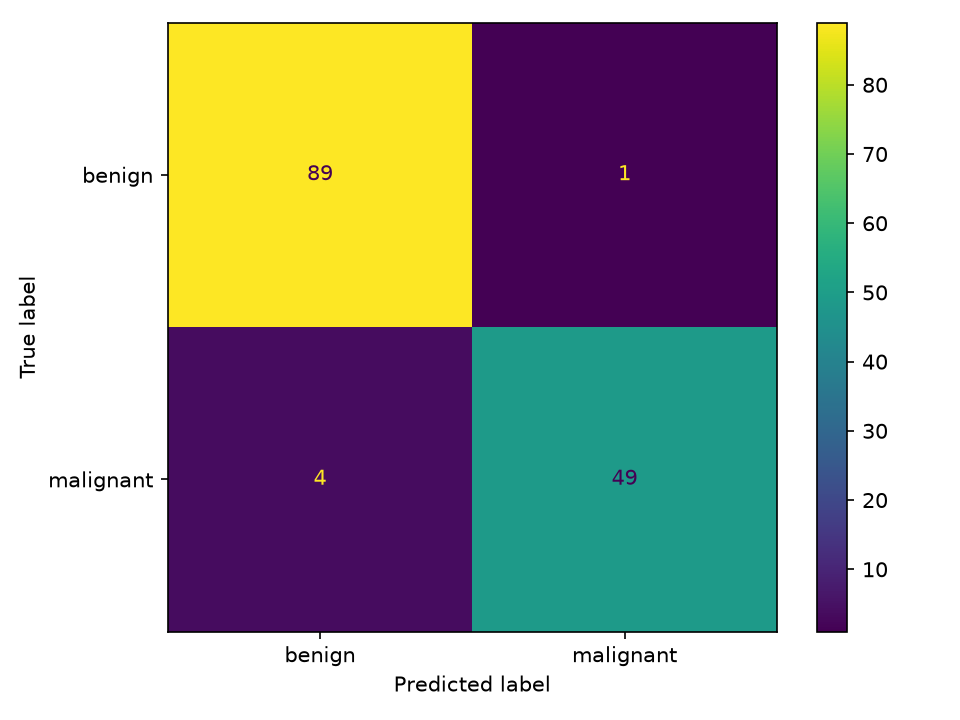

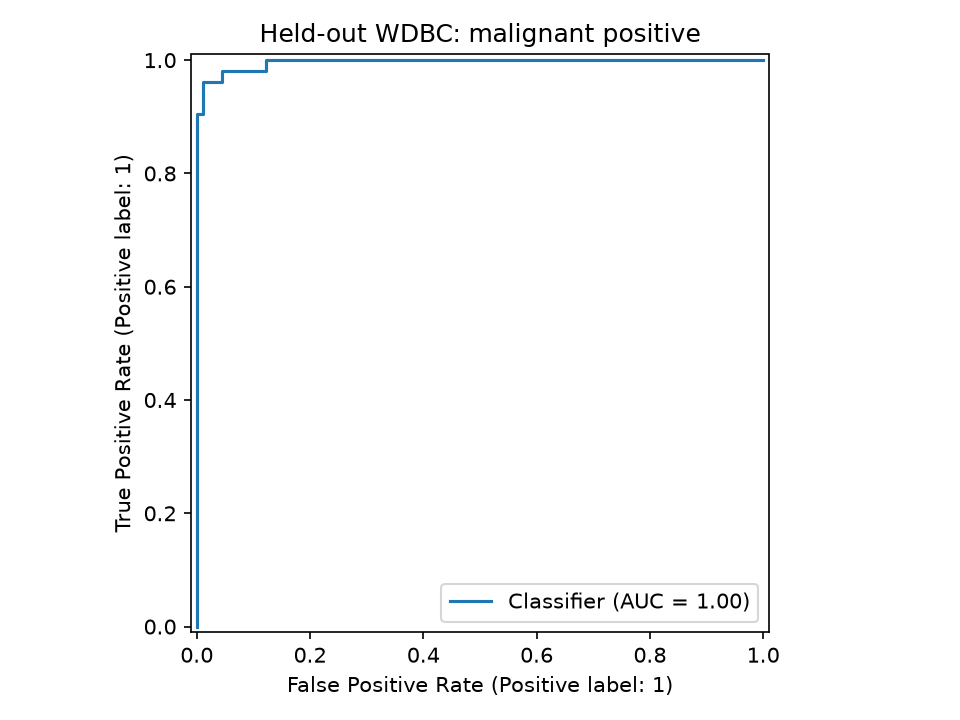

In [2]:
from IPython.display import Image, display
for figure in sorted(run_dir.glob("*.png")):
    display(Image(filename=str(figure)))

## Interpretation
Pozitiv sinif malignant-dir. Yüksək internal AUROC prospective clinical benefit-i təsdiq etmir.

## Conclusion
Növbəti addım independent cohort və calibration audit-dir.